In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Colleciton

In [7]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end);
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-27,20.952881,21.182808,20.829950,21.171424,181958400
2016-06-28,21.305729,21.321666,20.975638,21.148652,161779600
2016-06-29,21.490126,21.524273,21.314834,21.392236,146124000
2016-06-30,21.763304,21.802004,21.467360,21.499231,143345600
2016-07-01,21.829321,21.961358,21.701838,21.738261,104106000
...,...,...,...,...,...
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900


In [8]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-27,20.952881,21.182808,20.829950,21.171424,181958400
2016-06-28,21.305729,21.321666,20.975638,21.148652,161779600
2016-06-29,21.490126,21.524273,21.314834,21.392236,146124000
2016-06-30,21.763304,21.802004,21.467360,21.499231,143345600
2016-07-01,21.829321,21.961358,21.701838,21.738261,104106000


In [9]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900
2026-06-25,275.149994,288.799988,273.750000,287.399994,107253700
2026-06-26,NaN,NaN,NaN,NaN,261244321


# 2. Data Exploration & Visualization

In [10]:
type(df)

pandas.DataFrame

In [11]:
df.shape

(2514, 5)

In [12]:
df.isna().sum()

Price   Ticker
Close   AAPL      1
High    AAPL      1
Low     AAPL      1
Open    AAPL      1
Volume  AAPL      0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [17]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,126.061073,127.330848,124.691387,125.957656,9.582184e+07
std,77.688780,78.469393,76.887264,77.647116,5.459573e+07
min,20.952881,21.182808,20.829950,21.148652,1.791060e+07
25%,45.473824,45.756575,44.979032,45.426907,5.669700e+07
50%,130.774765,132.019338,129.573780,131.055407,8.411800e+07
75%,182.187744,183.687513,180.301469,181.860483,1.159568e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [18]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [22]:
df = df.reset_index()
df

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL
0,0,2016-06-27,20.952881,21.182808,20.829950,21.171424,181958400
1,1,2016-06-28,21.305729,21.321666,20.975638,21.148652,161779600
2,2,2016-06-29,21.490126,21.524273,21.314834,21.392236,146124000
3,3,2016-06-30,21.763304,21.802004,21.467360,21.499231,143345600
4,4,2016-07-01,21.829321,21.961358,21.701838,21.738261,104106000
...,...,...,...,...,...,...,...
2508,2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200
2509,2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2510,2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900


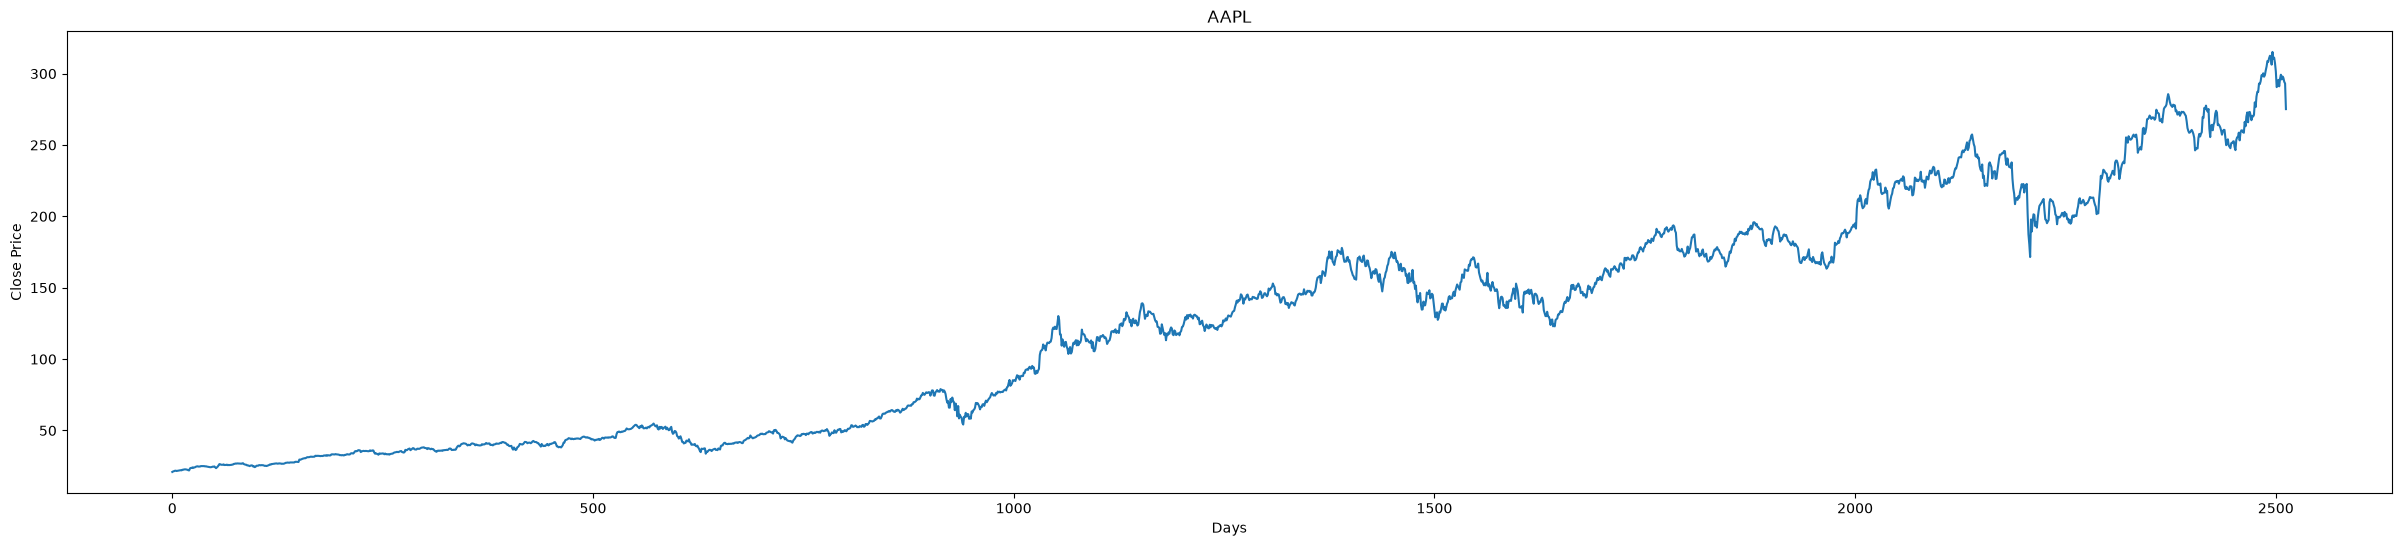

In [34]:
plt.figure(figsize=(30,6))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.show()

# 3. Feature Engineering

### We reduce noise by applying a moving average smoothing technique

In [ ]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# # MA: Moving Average
# MA of 5 days ==> null null null null null 30 40 50 60 70 ...

In [36]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[:5]) / 5)

30.0


In [38]:
df1  = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [43]:
df1['MA_5'] = df1[0].rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 Days Moving Average

In [46]:
df['MA_100'] = df.Close.rolling(100).mean()
df.tail()

Price,index,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,
2508,2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,274.548561
2509,2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750
2510,2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106
2511,2511,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,275.676895
2512,2512,2026-06-25,275.149994,288.799988,273.750000,287.399994,107253700,275.838407


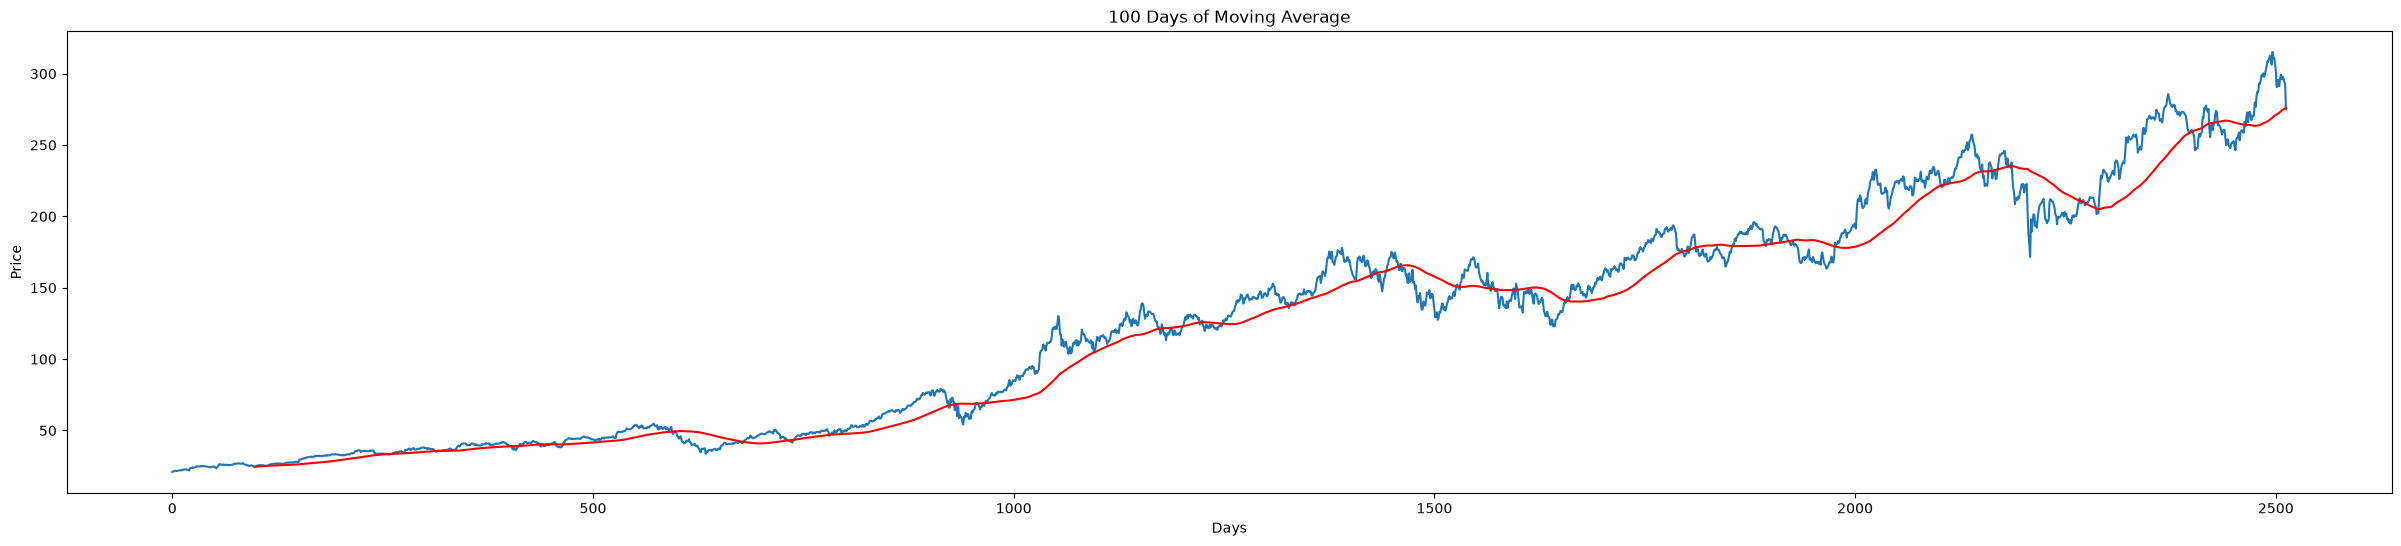

In [54]:
plt.figure(figsize=(30,6))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days of Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()

### 200 Days Moving Average

In [55]:
df['MA_200'] = df.Close.rolling(200).mean()
df.tail()

Price,index,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,,
2508,2508,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200,274.548561,267.793002
2509,2509,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750,268.089066
2510,2510,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106,268.365048
2511,2511,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,275.676895,268.635379
2512,2512,2026-06-25,275.149994,288.799988,273.750000,287.399994,107253700,275.838407,268.825084


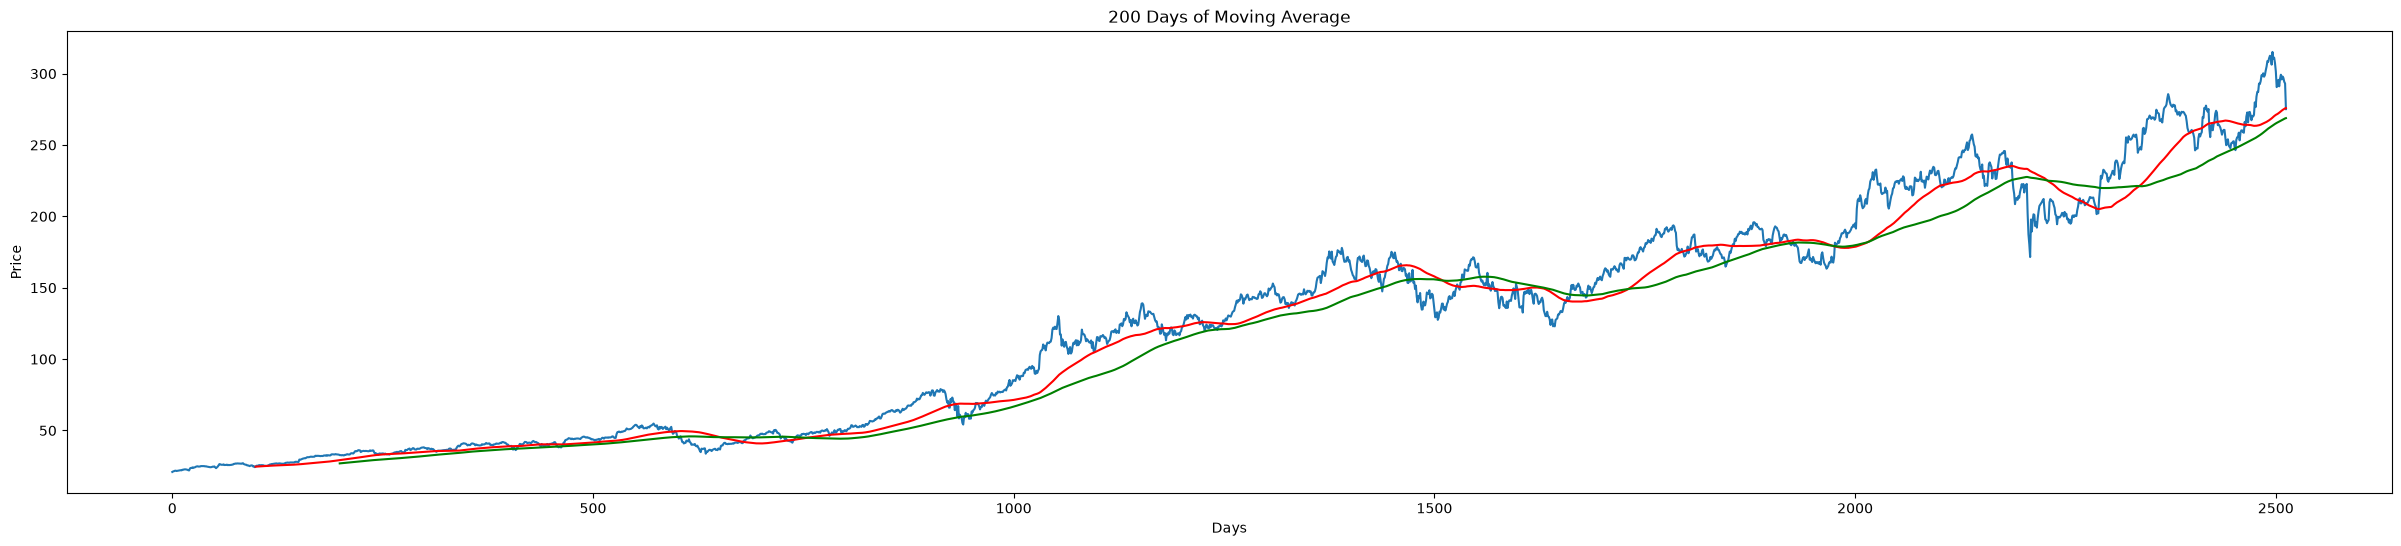

In [58]:
plt.figure(figsize=(30,6))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days of Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()

### Calculating % changed in each trading session

In [60]:
df['%_changed'] = df.Close.pct_change()
df[['Close', '%_changed']]

Price,Close,%_changed
Ticker,AAPL,
0,20.952881,NaN
1,21.305729,0.016840
2,21.490126,0.008655
3,21.763304,0.012712
4,21.829321,0.003033
...,...,...
2508,298.010010,0.006961
2509,297.010010,-0.003356
2510,294.299988,-0.009124


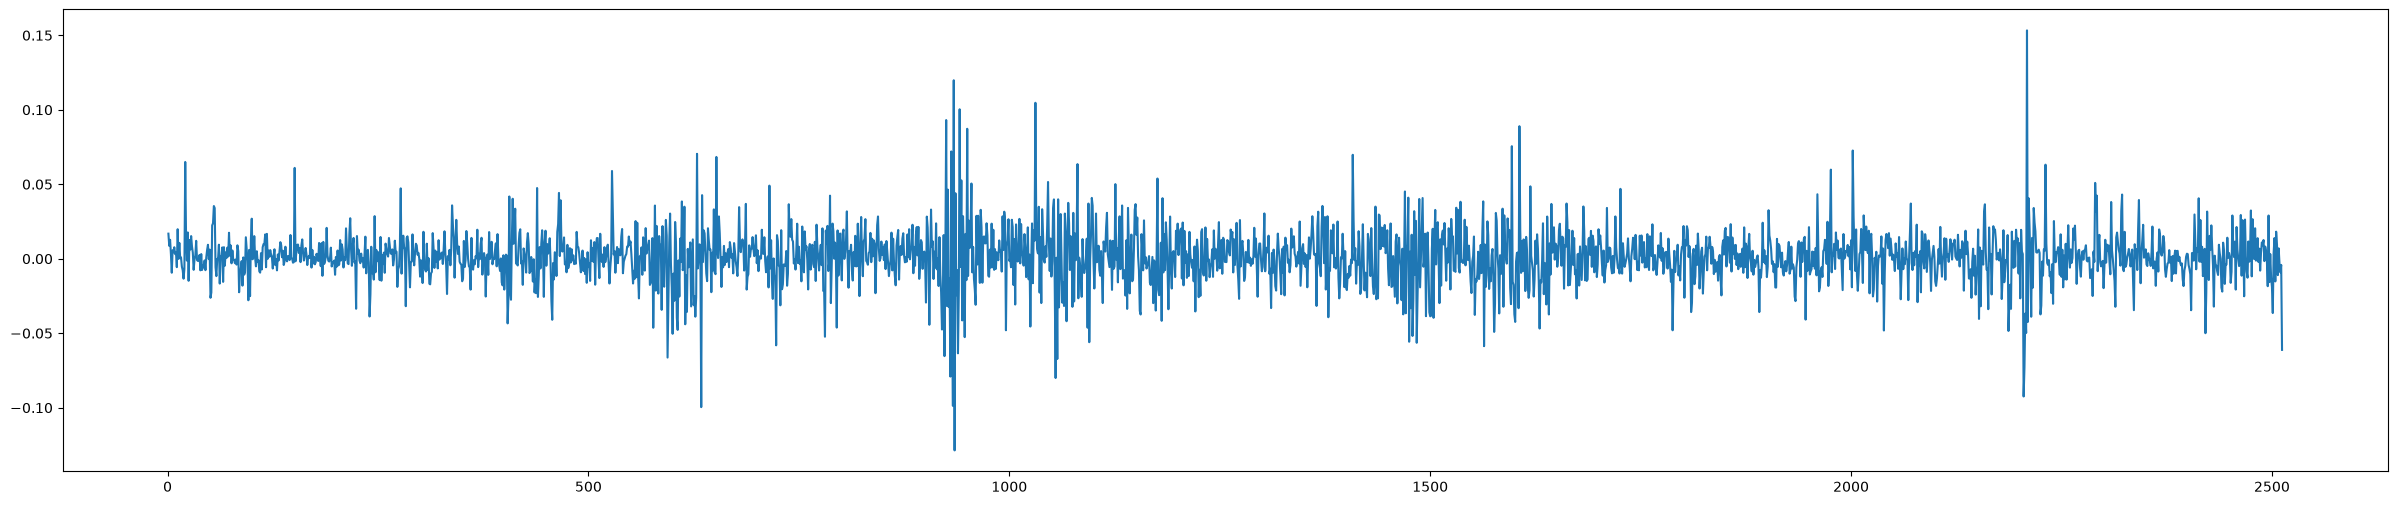

In [63]:
plt.figure(figsize=(30,6))
plt.plot(df['%_changed'])
plt.show()

# 4. Data Preprocessing

In [64]:
df.shape

(2513, 10)

### Splitting the data into Trainig & Testing datasets

70% of data = Trainig

30% of data = Testing

In [85]:
data_training = pd.DataFrame(df.Close[0:int(len(df) * 0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df) * 0.7):len(df)])

data_training

Ticker,AAPL
0,20.952881
1,21.305729
2,21.490126
3,21.763304
4,21.829321
...,...
1754,183.438339
1755,182.363403
1756,182.452179
1757,181.416687


In [86]:
type(data_training)

pandas.DataFrame

In [76]:
data_testing

Ticker,AAPL
1759,184.099060
1760,182.708572
1761,185.460007
1762,186.633545
1763,186.968857
...,...
2508,298.010010
2509,297.010010
2510,294.299988
2511,293.079987


## Scaling down the data between 0 and 1

In [81]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

In [83]:
data_training_arr = scaler.fit_transform(data_training)
data_training_arr

array([[0.        ],
       [0.0021586 ],
       [0.00328667],
       ...,
       [0.98799436],
       [0.98165959],
       [1.        ]], shape=(1759, 1))

In [87]:
type(data_training_arr)

numpy.ndarray

In [88]:
data_training_arr.shape

(1759, 1)

# 5. Sequence Creation

In [89]:
# Prediction pattern: 13, 12, 15, 10, 14, 16, 18, 19, 20, 21 => 20

In [93]:
x_train = []
y_train = []

for i in range(100, data_training_arr.shape[0]):
    x_train.append(data_training_arr[i-100: i])
    y_train.append(data_training_arr[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [94]:
x_train

array([[[0.        ],
        [0.0021586 ],
        [0.00328667],
        ...,
        [0.02442348],
        [0.02059536],
        [0.0225657 ]],

       [[0.0021586 ],
        [0.00328667],
        [0.00495787],
        ...,
        [0.02059536],
        [0.0225657 ],
        [0.02661906]],

       [[0.00328667],
        [0.00495787],
        [0.00536174],
        ...,
        [0.0225657 ],
        [0.02661906],
        [0.02656277]],

       ...,

       [[0.7251827 ],
        [0.73781518],
        [0.74966586],
        ...,
        [0.9815992 ],
        [0.99402733],
        [0.98745126]],

       [[0.73781518],
        [0.74966586],
        [0.73204022],
        ...,
        [0.99402733],
        [0.98745126],
        [0.98799436]],

       [[0.74966586],
        [0.73204022],
        [0.73980031],
        ...,
        [0.98745126],
        [0.98799436],
        [0.98165959]]], shape=(1659, 100, 1))

In [96]:
x_train.ndim

3

In [97]:
y_train.ndim

1

In [99]:
x_train.shape

(1659, 100, 1)

In [98]:
y_train.shape

(1659,)

# 6. Model Building

In [104]:
import tensorflow as tf

In [108]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [115]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [119]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0016
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 6.0010e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 4.7703e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 4.9736e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 4.6478e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 3.7062e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 3.4093e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.0598e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.9358e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 3.1787e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 3.0937e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 3.0605e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 2.6489e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 3.9398e-04
Epoch 15/50
52/52 ━

### Showing Model Results

In [120]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

### Saving the training model

In [121]:
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [123]:
data_training

Ticker,AAPL
0,20.952881
1,21.305729
2,21.490126
3,21.763304
4,21.829321
...,...
1754,183.438339
1755,182.363403
1756,182.452179
1757,181.416687


In [122]:
data_testing

Ticker,AAPL
1759,184.099060
1760,182.708572
1761,185.460007
1762,186.633545
1763,186.968857
...,...
2508,298.010010
2509,297.010010
2510,294.299988
2511,293.079987


In [125]:
past_100_days = data_training.tail(100)
past_100_days

Ticker,AAPL
1659,140.613464
1660,141.881943
1661,143.002899
1662,148.302979
1663,151.921555
...,...
1754,183.438339
1755,182.363403
1756,182.452179
1757,181.416687


In [128]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,140.613464
1,141.881943
2,143.002899
3,148.302979
4,151.921555
...,...
849,298.010010
850,297.010010
851,294.299988
852,293.079987


In [129]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.        ],
       [0.00726561],
       [0.01368625],
       [0.04404414],
       [0.06477068],
       [0.04916934],
       [0.0656154 ],
       [0.05023963],
       [0.04432574],
       [0.04641275],
       [0.06243275],
       [0.05876625],
       [0.07078133],
       [0.06164318],
       [0.05509975],
       [0.03214145],
       [0.03456705],
       [0.03733107],
       [0.02215745],
       [0.02898257],
       [0.0261059 ],
       [0.01426003],
       [0.01764457],
       [0.04652559],
       [0.06232009],
       [0.04974102],
       [0.05690481],
       [0.04404361],
       [0.0322542 ],
       [0.04336705],
       [0.05532533],
       [0.05758163],
       [0.07371428],
       [0.06891972],
       [0.08245756],
       [0.09306254],
       [0.08488334],
       [0.09108809],
       [0.0985341 ],
       [0.08742168],
       [0.08386801],
       [0.10146732],
       [0.11043617],
       [0.12476393],
       [0.13192781],
       [0.12888176],
       [0.11833334],
       [0.123

In [130]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [131]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [134]:
x_test[0]

array([[0.        ],
       [0.00726561],
       [0.01368625],
       [0.04404414],
       [0.06477068],
       [0.04916934],
       [0.0656154 ],
       [0.05023963],
       [0.04432574],
       [0.04641275],
       [0.06243275],
       [0.05876625],
       [0.07078133],
       [0.06164318],
       [0.05509975],
       [0.03214145],
       [0.03456705],
       [0.03733107],
       [0.02215745],
       [0.02898257],
       [0.0261059 ],
       [0.01426003],
       [0.01764457],
       [0.04652559],
       [0.06232009],
       [0.04974102],
       [0.05690481],
       [0.04404361],
       [0.0322542 ],
       [0.04336705],
       [0.05532533],
       [0.05758163],
       [0.07371428],
       [0.06891972],
       [0.08245756],
       [0.09306254],
       [0.08488334],
       [0.09108809],
       [0.0985341 ],
       [0.08742168],
       [0.08386801],
       [0.10146732],
       [0.11043617],
       [0.12476393],
       [0.13192781],
       [0.12888176],
       [0.11833334],
       [0.123

In [136]:
y_test

array([0.24907758, 0.24111312, 0.25687284, 0.26359465, 0.26551526,
       0.29025633, 0.28172683, 0.27534395, 0.27805526, 0.2716723 ,
       0.25997955, 0.25698576, 0.26653198, 0.27088142, 0.27172876,
       0.29036907, 0.28890041, 0.29663929, 0.28551132, 0.27878951,
       0.28336479, 0.28827909, 0.29325011, 0.28601963, 0.30076272,
       0.30426473, 0.29951998, 0.28240461, 0.27443998, 0.22258573,
       0.20484895, 0.21021519, 0.20112083, 0.1998781 , 0.20021747,
       0.20966353, 0.19829433, 0.19331701, 0.17878045, 0.18155189,
       0.18918782, 0.19704985, 0.21905277, 0.19224252, 0.20485559,
       0.21379263, 0.23602149, 0.25598827, 0.25723258, 0.26622625,
       0.26758357, 0.22917758, 0.19891653, 0.20242352, 0.20909779,
       0.19178979, 0.17996812, 0.18862225, 0.18449289, 0.20123567,
       0.20745756, 0.18720813, 0.17838436, 0.18324875, 0.19054531,
       0.1672417 , 0.15858757, 0.16005806, 0.16299941, 0.17736633,
       0.16973031, 0.17685731, 0.18392759, 0.19852069, 0.20700

# 9. Making Predictions

In [137]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [138]:
y_predicted

array([[0.25155926],
       [0.2539166 ],
       [0.24900173],
       [0.25821954],
       [0.2660453 ],
       [0.2697602 ],
       [0.28825605],
       [0.28799325],
       [0.2831323 ],
       [0.283632  ],
       [0.27938932],
       [0.26986295],
       [0.26488346],
       [0.27015045],
       [0.27492395],
       [0.2768956 ],
       [0.29062364],
       [0.29377887],
       [0.30008942],
       [0.29400477],
       [0.28736705],
       [0.28877845],
       [0.2928391 ],
       [0.2976152 ],
       [0.29381427],
       [0.3032362 ],
       [0.3086345 ],
       [0.3066833 ],
       [0.29377073],
       [0.28437713],
       [0.24538189],
       [0.22131644],
       [0.21765588],
       [0.21068469],
       [0.20739175],
       [0.20649976],
       [0.21245241],
       [0.20698674],
       [0.20154974],
       [0.1901827 ],
       [0.187993  ],
       [0.1925198 ],
       [0.19946793],
       [0.21652335],
       [0.2048442 ],
       [0.20854728],
       [0.21624358],
       [0.233

### Inverse Transformation

Inverse transformation is the process of reverting scaled data back to its original values.

In [139]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [140]:
y_predicted

array([184.53233, 184.9439 , 184.08582, 185.69511, 187.0614 , 187.70996,
       190.93909, 190.8932 , 190.04456, 190.1318 , 189.39107, 187.72789,
       186.85854, 187.77809, 188.61148, 188.95572, 191.35245, 191.9033 ,
       193.00504, 191.94275, 190.78387, 191.03029, 191.73923, 192.57307,
       191.90948, 193.55441, 194.4969 , 194.15625, 191.90187, 190.26189,
       183.45383, 179.25233, 178.61325, 177.39618, 176.82127, 176.66553,
       177.7048 , 176.75058, 175.80135, 173.8168 , 173.43451, 174.22482,
       175.43788, 178.41551, 176.37651, 177.02301, 178.3667 , 181.45674,
       184.9098 , 186.1877 , 187.64485, 188.2816 , 183.82724, 178.79987,
       177.61452, 178.08614, 176.25156, 174.20377, 174.47284, 174.13293,
       175.8954 , 177.25655, 175.35768, 173.60968, 173.56519, 174.42992,
       172.10744, 170.23656, 169.7556 , 169.95674, 171.65842, 171.45319,
       172.11684, 173.17815, 175.22725, 176.94907, 177.14278, 178.09647,
       179.04811, 178.14989, 177.72702, 176.57692, 

In [141]:
y_test

array([184.09906006, 182.70857239, 185.46000671, 186.63354492,
       186.96885681, 191.28831482, 189.79917908, 188.68481445,
       189.15817261, 188.04379272, 186.00239563, 185.47972107,
       187.1463623 , 187.90571594, 188.0536499 , 191.30799866,
       191.05158997, 192.4026947 , 190.4598999 , 189.28636169,
       190.08514404, 190.94311523, 191.81098938, 190.54864502,
       193.12258911, 193.73399353, 192.90562439, 189.91751099,
       188.5269928 , 179.47393799, 176.37733459, 177.31420898,
       175.72645569, 175.50949097, 175.56874084, 177.21789551,
       175.23298645, 174.36401367, 171.8261261 , 172.3099823 ,
       173.64311218, 175.01571655, 178.85713196, 174.17642212,
       176.37849426, 177.93878174, 181.81964111, 185.30557251,
       185.52281189, 187.09298706, 187.32995605, 180.62478638,
       175.34161377, 175.95388794, 177.11912537, 174.09738159,
       172.03347778, 173.54437256, 172.82344055, 175.74650574,
       176.83276367, 173.29748535, 171.75697327, 172.60

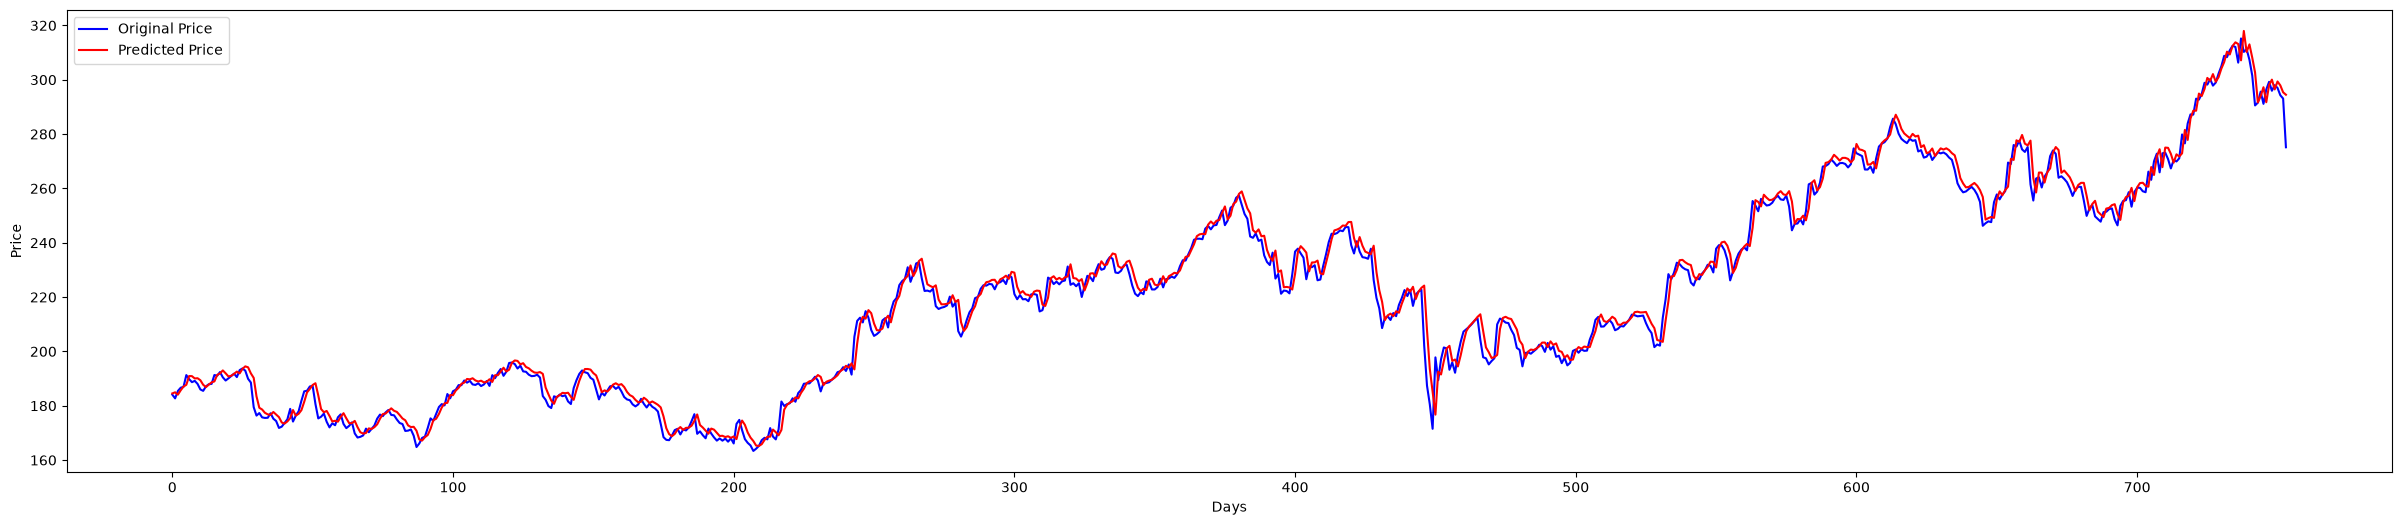

In [144]:
plt.figure(figsize=(30, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

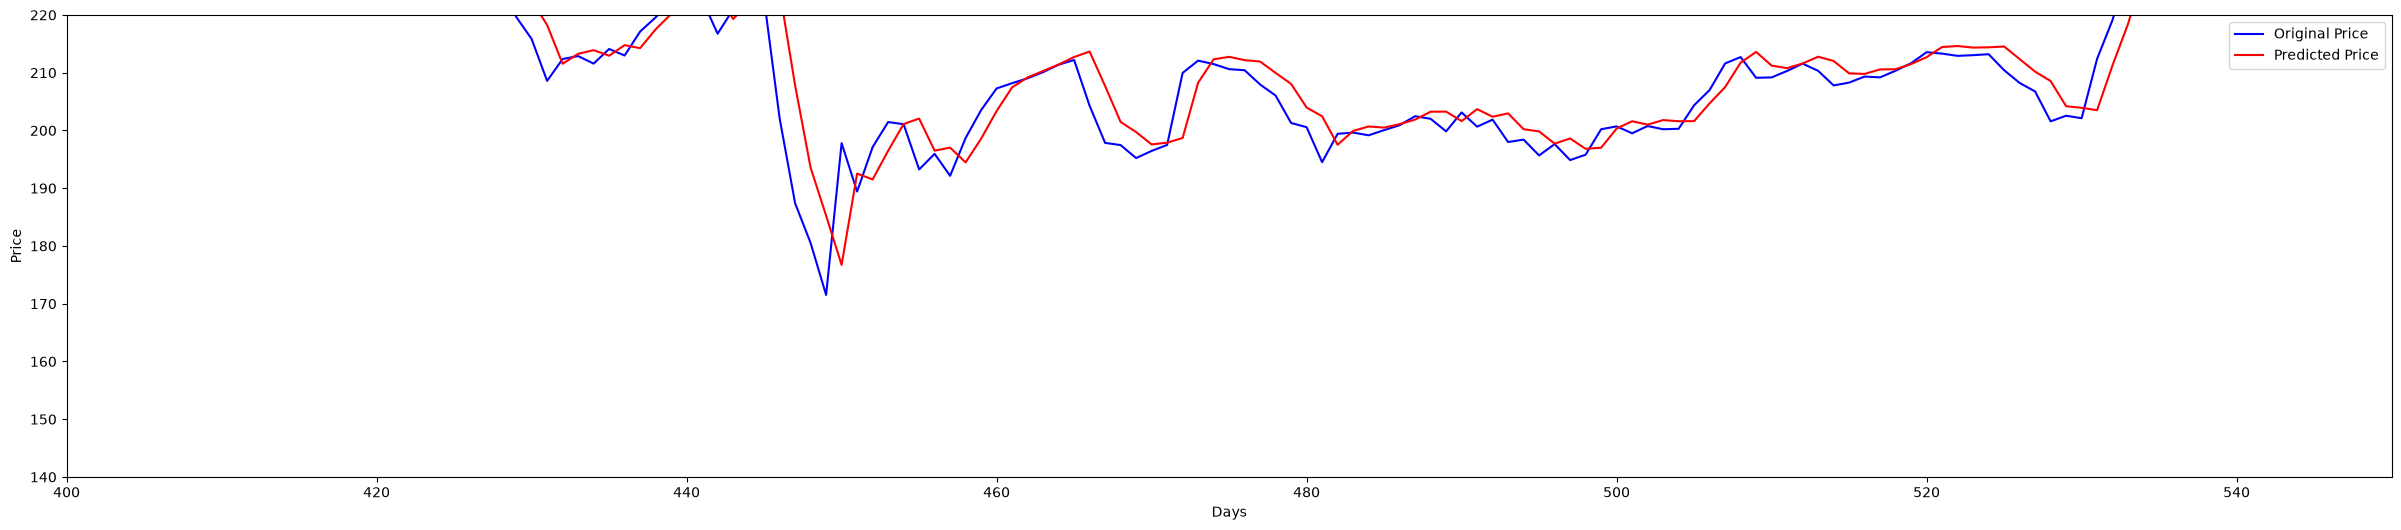

In [145]:
plt.figure(figsize=(30, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(400, 550)
plt.ylim(140, 220)
plt.show()

# 10. Model Evaluation

### Mean Squared Error (MSE)

In [153]:
from sklearn.metrics import mean_squared_error, r2_score

In [151]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 15.365842154943097


### Root Mean Squared Error (RMSE)

In [152]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 3.919928845647979


### R-Squared

In [156]:
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9884530086313253
